In [10]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt

sys.path.append('..')

from rl.environment import NexResolveEnv
from rl.bandit_policy import LinUCB, ThompsonSampling
from rl.action_masking import get_action_mask

## 1. Rolling Evaluation

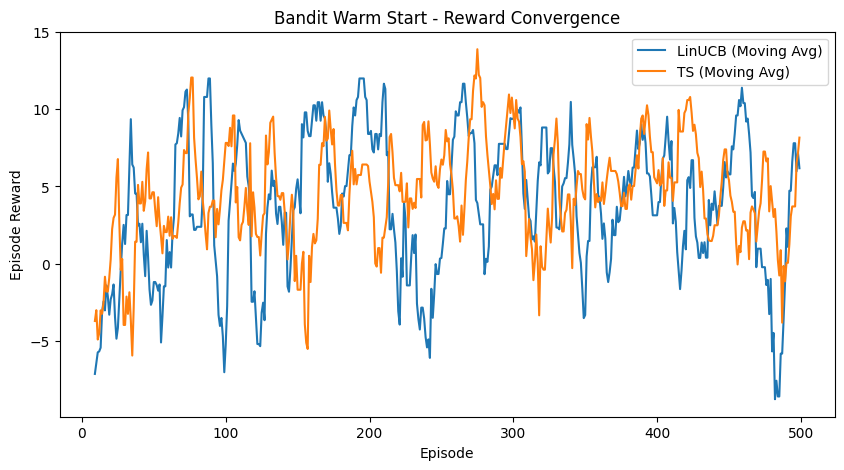

In [17]:
def evaluate_policy(policy, n_episodes=500):
    env = NexResolveEnv('../data/final/rl_ready_dataset.csv')
    rewards = []
    
    for i in range(n_episodes):
        state = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            mask = get_action_mask(state)
            action = policy.select_action(state, mask=mask)
            next_state, reward, done, _ = env.step(action)
            policy.update(state, action, reward)
            
            episode_reward += reward
            state = next_state
            
        rewards.append(episode_reward)
        
    return rewards

linucb = LinUCB(alpha=1.0)
ts = ThompsonSampling(v=0.1)

rewards_linucb = evaluate_policy(linucb)
rewards_ts = evaluate_policy(ts)

plt.figure(figsize=(10, 5))
plt.plot(pd.Series(rewards_linucb).rolling(10).mean(), label="LinUCB (Moving Avg)")
plt.plot(pd.Series(rewards_ts).rolling(10).mean(), label="TS (Moving Avg)")
plt.title("Bandit Warm Start - Reward Convergence")
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.legend()
plt.show()